# Energy Performance Dashboard

## 1. Introduction

Ce projet propose un exemple de suivi de performance énergétique sur un réseau de chaleur à partir de données journalières simulées.

L'objectif est de contrôler la qualité des données, de calculer quelques indicateurs simples et de produire un dashboard lisible pour aider au pilotage métier : énergie livrée, pertes réseau, rendement, anomalies et fiabilité des données.


## 2. Import des librairies


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 3. Création ou chargement des données

Le notebook charge le fichier CSV s'il existe. Sinon, il génère un jeu de données fictif mais réaliste pour 4 sites clients sur 240 jours.

Quelques anomalies sont ajoutées volontairement : valeurs manquantes, valeurs négatives, pics, rendements supérieurs à 1 et incohérences entre énergie produite et énergie livrée.


In [2]:
cwd = Path.cwd()
if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif cwd.name == "notebooks" and (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = DATA_DIR / "reseau_chaleur_sample.csv"

DATA_PATH


WindowsPath('C:/00_VSC_Projects/Projets_Github/energy-performance-dashboard/data/reseau_chaleur_sample.csv')

In [3]:
def generer_donnees(path: Path, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    sites = {
        "Centre-ville": {"base": 18.0, "sensibilite": 2.3},
        "Quartier Nord": {"base": 13.5, "sensibilite": 1.9},
        "Hôpital": {"base": 24.0, "sensibilite": 2.8},
        "Campus": {"base": 10.0, "sensibilite": 1.5},
    }

    dates = pd.date_range("2025-01-01", periods=240, freq="D")
    lignes = []

    for date_jour in dates:
        day_of_year = date_jour.dayofyear
        temp_base = 11 + 10 * np.sin(2 * np.pi * (day_of_year - 80) / 365)
        temperature = temp_base + rng.normal(0, 2.2)

        for site, params in sites.items():
            besoin_chauffage = max(0, 16 - temperature)
            energie_livree = params["base"] + besoin_chauffage * params["sensibilite"] + rng.normal(0, params["base"] * 0.08)
            energie_livree = max(energie_livree, params["base"] * 0.55)
            rendement = np.clip(rng.normal(0.905, 0.018), 0.84, 0.95)
            energie_produite = energie_livree / rendement
            pertes = energie_produite - energie_livree
            conso_corrigee = energie_livree / max(0.65, 1 + (15 - temperature) / 30)

            lignes.append(
                {
                    "date": date_jour,
                    "site": site,
                    "temperature_exterieure_moyenne": round(temperature, 2),
                    "energie_produite_mwh": round(energie_produite, 2),
                    "energie_livree_mwh": round(energie_livree, 2),
                    "pertes_reseau_mwh": round(pertes, 2),
                    "rendement_reseau": round(energie_livree / energie_produite, 3),
                    "consommation_corrigee_climat": round(conso_corrigee, 2),
                    "taux_donnees_manquantes": round(max(0, rng.normal(0.012, 0.008)), 3),
                    "flag_anomalie": False,
                    "commentaire_qualite_donnees": "OK",
                }
            )

    df_gen = pd.DataFrame(lignes)
    index_anomalies = rng.choice(df_gen.index, size=32, replace=False)

    for idx in index_anomalies[:12]:
        colonne = rng.choice(["temperature_exterieure_moyenne", "energie_livree_mwh"])
        df_gen.loc[idx, colonne] = np.nan
        df_gen.loc[idx, "taux_donnees_manquantes"] = 0.25
        df_gen.loc[idx, "flag_anomalie"] = True
        df_gen.loc[idx, "commentaire_qualite_donnees"] = "Valeur manquante à contrôler"

    for idx in index_anomalies[12:17]:
        df_gen.loc[idx, "energie_produite_mwh"] = -abs(df_gen.loc[idx, "energie_produite_mwh"])
        df_gen.loc[idx, ["pertes_reseau_mwh", "rendement_reseau"]] = np.nan
        df_gen.loc[idx, "flag_anomalie"] = True
        df_gen.loc[idx, "commentaire_qualite_donnees"] = "Valeur négative impossible"

    for idx in index_anomalies[17:23]:
        df_gen.loc[idx, "energie_livree_mwh"] *= rng.uniform(2.5, 3.2)
        df_gen.loc[idx, "rendement_reseau"] = df_gen.loc[idx, "energie_livree_mwh"] / df_gen.loc[idx, "energie_produite_mwh"]
        df_gen.loc[idx, "pertes_reseau_mwh"] = df_gen.loc[idx, "energie_produite_mwh"] - df_gen.loc[idx, "energie_livree_mwh"]
        df_gen.loc[idx, "flag_anomalie"] = True
        df_gen.loc[idx, "commentaire_qualite_donnees"] = "Pic anormal de livraison"

    for idx in index_anomalies[23:28]:
        df_gen.loc[idx, "energie_livree_mwh"] = df_gen.loc[idx, "energie_produite_mwh"] * rng.uniform(1.03, 1.09)
        df_gen.loc[idx, "rendement_reseau"] = df_gen.loc[idx, "energie_livree_mwh"] / df_gen.loc[idx, "energie_produite_mwh"]
        df_gen.loc[idx, "pertes_reseau_mwh"] = df_gen.loc[idx, "energie_produite_mwh"] - df_gen.loc[idx, "energie_livree_mwh"]
        df_gen.loc[idx, "flag_anomalie"] = True
        df_gen.loc[idx, "commentaire_qualite_donnees"] = "Rendement supérieur à 1"

    for idx in index_anomalies[28:]:
        df_gen.loc[idx, "energie_livree_mwh"] = df_gen.loc[idx, "energie_produite_mwh"] * rng.uniform(1.10, 1.18)
        df_gen.loc[idx, "pertes_reseau_mwh"] = df_gen.loc[idx, "energie_produite_mwh"] - df_gen.loc[idx, "energie_livree_mwh"]
        df_gen.loc[idx, "flag_anomalie"] = True
        df_gen.loc[idx, "commentaire_qualite_donnees"] = "Énergie livrée supérieure à l'énergie produite"

    df_gen.to_csv(path, index=False, encoding="utf-8")
    return df_gen


if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH, parse_dates=["date"], encoding="utf-8")
else:
    df = generer_donnees(DATA_PATH)

df.head()


,date,site,temperature_exterieure_moyenne,energie_produite_mwh,energie_livree_mwh,pertes_reseau_mwh,rendement_reseau,consommation_corrigee_climat,taux_donnees_manquantes,flag_anomalie,commentaire_qualite_donnees
0,2025-01-01,Centre-ville,0.9,58.11,52.47,5.64,0.903,35.70,0.018,False,OK
1,2025-01-01,Quartier Nord,0.9,47.88,42.04,5.84,0.878,28.60,0.015,False,OK
2,2025-01-01,Hôpital,0.9,72.97,65.75,7.22,0.901,44.74,0.013,False,OK
3,2025-01-01,Campus,0.9,35.45,32.83,2.63,0.926,22.33,0.017,False,OK
4,2025-01-02,Centre-ville,1.5,56.70,50.28,6.42,0.887,34.68,0.014,False,OK


In [4]:
print(f"Nombre de lignes : {len(df):,}".replace(",", " "))
print(f"Période : {df['date'].min().date()} au {df['date'].max().date()}")
print(f"Nombre de sites : {df['site'].nunique()}")


Nombre de lignes : 960
Période : 2025-01-01 au 2025-08-28
Nombre de sites : 4


## 4. Contrôle qualité des données

Les règles restent simples pour être faciles à expliquer :

$$Rendement = \frac{\text{Énergie livrée}}{\text{Énergie produite}}$$

$$z = \frac{x - \mu}{\sigma}$$


In [5]:
valeurs_manquantes = df.isna().sum().to_frame("valeurs_manquantes")
valeurs_manquantes


,valeurs_manquantes
date,0
site,0
temperature_exterieure_moyenne,6
energie_produite_mwh,0
energie_livree_mwh,6
pertes_reseau_mwh,5
rendement_reseau,11
consommation_corrigee_climat,0
taux_donnees_manquantes,0
flag_anomalie,0


In [6]:
df_q = df.copy()

df_q["rendement_calcule"] = df_q["energie_livree_mwh"] / df_q["energie_produite_mwh"]

z_score = df_q.groupby("site")["energie_livree_mwh"].transform(
    lambda serie: (serie - serie.mean()) / serie.std(ddof=0)
)
df_q["z_score_livraison"] = z_score

regles = pd.DataFrame(
    {
        "donnees_manquantes": df_q[
            [
                "temperature_exterieure_moyenne",
                "energie_produite_mwh",
                "energie_livree_mwh",
                "rendement_reseau",
            ]
        ].isna().any(axis=1),
        "valeurs_impossibles": (
            (df_q["energie_produite_mwh"] < 0)
            | (df_q["energie_livree_mwh"] < 0)
            | (df_q["pertes_reseau_mwh"] < -0.01)
        ),
        "rendement_incoherent": (
            (df_q["rendement_reseau"] > 1)
            | (df_q["rendement_calcule"] > 1)
            | (df_q["rendement_reseau"] < 0)
        ),
        "incoherence_energie": df_q["energie_livree_mwh"] > df_q["energie_produite_mwh"] * 1.02,
        "pic_livraison": df_q["z_score_livraison"].abs() > 3,
    }
)

df_q["quality_flag"] = np.where(regles.any(axis=1), "A contrôler", "OK")
df_q["controle_qualite"] = regles.apply(
    lambda row: ", ".join(row.index[row]) if row.any() else "OK",
    axis=1,
)

synthese_qualite = regles.sum().sort_values(ascending=False).to_frame("nombre_lignes")
synthese_qualite


,nombre_lignes
valeurs_impossibles,20
incoherence_energie,20
donnees_manquantes,17
rendement_incoherent,15
pic_livraison,4


In [7]:
df_q.loc[df_q["quality_flag"] != "OK", [
    "date",
    "site",
    "energie_produite_mwh",
    "energie_livree_mwh",
    "rendement_reseau",
    "quality_flag",
    "controle_qualite",
]].head(10)


,date,site,energie_produite_mwh,energie_livree_mwh,rendement_reseau,quality_flag,controle_qualite
38,2025-01-10,Hôpital,63.49,155.74,2.453,A contrôler,"valeurs_impossibles, rendement_incoherent, inc..."
39,2025-01-10,Campus,29.30,30.89,1.054,A contrôler,"valeurs_impossibles, rendement_incoherent, inc..."
103,2025-01-26,Campus,30.25,27.55,0.911,A contrôler,donnees_manquantes
147,2025-02-06,Campus,32.68,86.66,2.652,A contrôler,"valeurs_impossibles, rendement_incoherent, inc..."
176,2025-02-14,Centre-ville,44.57,121.28,2.721,A contrôler,"valeurs_impossibles, rendement_incoherent, inc..."
270,2025-03-09,Hôpital,53.73,NaN,NaN,A contrôler,donnees_manquantes
282,2025-03-12,Hôpital,60.10,163.13,2.714,A contrôler,"valeurs_impossibles, rendement_incoherent, inc..."
292,2025-03-15,Centre-ville,38.95,33.32,0.855,A contrôler,donnees_manquantes
339,2025-03-26,Campus,15.95,17.62,0.926,A contrôler,"valeurs_impossibles, rendement_incoherent, inc..."
352,2025-03-30,Centre-ville,36.49,NaN,NaN,A contrôler,donnees_manquantes


## 5. Nettoyage simple

Les anomalies sont conservées dans une table d'audit. Pour les indicateurs, les valeurs impossibles ou incohérentes sont remplacées par `NaN`, puis imputées avec une médiane par site.


In [8]:
anomalies_audit = df_q[df_q["quality_flag"] != "OK"].copy()

df_clean = df_q.copy()

masque_impossible = (
    (df_clean["energie_produite_mwh"] <= 0)
    | (df_clean["energie_livree_mwh"] <= 0)
    | (df_clean["energie_livree_mwh"] > df_clean["energie_produite_mwh"] * 1.02)
    | (df_clean["rendement_reseau"] > 1)
)

df_clean.loc[masque_impossible, ["energie_produite_mwh", "energie_livree_mwh", "rendement_reseau"]] = np.nan
df_clean.loc[regles["pic_livraison"], "energie_livree_mwh"] = np.nan

colonnes_a_imputer = [
    "temperature_exterieure_moyenne",
    "energie_produite_mwh",
    "energie_livree_mwh",
    "taux_donnees_manquantes",
]

for colonne in colonnes_a_imputer:
    df_clean[colonne] = df_clean.groupby("site")[colonne].transform(lambda serie: serie.fillna(serie.median()))

df_clean["pertes_reseau_mwh"] = df_clean["energie_produite_mwh"] - df_clean["energie_livree_mwh"]
df_clean["rendement_reseau"] = df_clean["energie_livree_mwh"] / df_clean["energie_produite_mwh"]
df_clean["consommation_corrigee_climat"] = df_clean["energie_livree_mwh"] / (
    1 + (15 - df_clean["temperature_exterieure_moyenne"]) / 30
).clip(lower=0.65)

print(f"Anomalies isolées pour audit : {len(anomalies_audit)}")
df_clean.head()


Anomalies isolées pour audit : 32


,date,site,temperature_exterieure_moyenne,energie_produite_mwh,energie_livree_mwh,pertes_reseau_mwh,rendement_reseau,consommation_corrigee_climat,taux_donnees_manquantes,flag_anomalie,commentaire_qualite_donnees,rendement_calcule,z_score_livraison,quality_flag,controle_qualite
0,2025-01-01,Centre-ville,0.9,58.11,52.47,5.64,0.902943,35.693878,0.018,False,OK,0.902943,1.706917,OK,OK
1,2025-01-01,Quartier Nord,0.9,47.88,42.04,5.84,0.878028,28.598639,0.015,False,OK,0.878028,1.996585,OK,OK
2,2025-01-01,Hôpital,0.9,72.97,65.75,7.22,0.901055,44.727891,0.013,False,OK,0.901055,1.514500,OK,OK
3,2025-01-01,Campus,0.9,35.45,32.83,2.62,0.926093,22.333333,0.017,False,OK,0.926093,1.750446,OK,OK
4,2025-01-02,Centre-ville,1.5,56.70,50.28,6.42,0.886772,34.675862,0.014,False,OK,0.886772,1.552440,OK,OK


## 6. Indicateurs de performance énergétique

$$Pertes\ réseau = Énergie\ produite - Énergie\ livrée$$

$$Taux\ de\ fiabilité = 1 - \frac{\text{Nombre de lignes avec anomalie}}{\text{Nombre total de lignes}}$$


In [9]:
kpi = {
    "Énergie produite totale (MWh)": df_clean["energie_produite_mwh"].sum(),
    "Énergie livrée totale (MWh)": df_clean["energie_livree_mwh"].sum(),
    "Pertes réseau (MWh)": df_clean["pertes_reseau_mwh"].sum(),
    "Rendement moyen": df_clean["rendement_reseau"].mean(),
    "Nombre d'anomalies détectées": len(anomalies_audit),
    "Taux de données fiables": (df_q["quality_flag"] == "OK").mean(),
}

site_plus_performant = df_clean.groupby("site")["rendement_reseau"].mean().idxmax()
site_plus_anomalies = anomalies_audit.groupby("site").size().idxmax()

kpi["Site le plus performant"] = site_plus_performant
kpi["Site avec le plus d'anomalies"] = site_plus_anomalies

kpi_df = pd.DataFrame(kpi.items(), columns=["Indicateur", "Valeur"])
kpi_df["Valeur"] = kpi_df["Valeur"].apply(lambda x: f"{x:,.2f}".replace(",", " ") if isinstance(x, float) else x)
kpi_df


,Indicateur,Valeur
0,Énergie produite totale (MWh),26 785.49
1,Énergie livrée totale (MWh),24 176.47
2,Pertes réseau (MWh),2 609.02
3,Rendement moyen,0.90
4,Nombre d'anomalies détectées,32
5,Taux de données fiables,0.97
6,Site le plus performant,Campus
7,Site avec le plus d'anomalies,Centre-ville


## 7. Visualisations / dashboard

Les graphiques sont produits avec `matplotlib` pour être visibles directement sur GitHub après exécution du notebook.


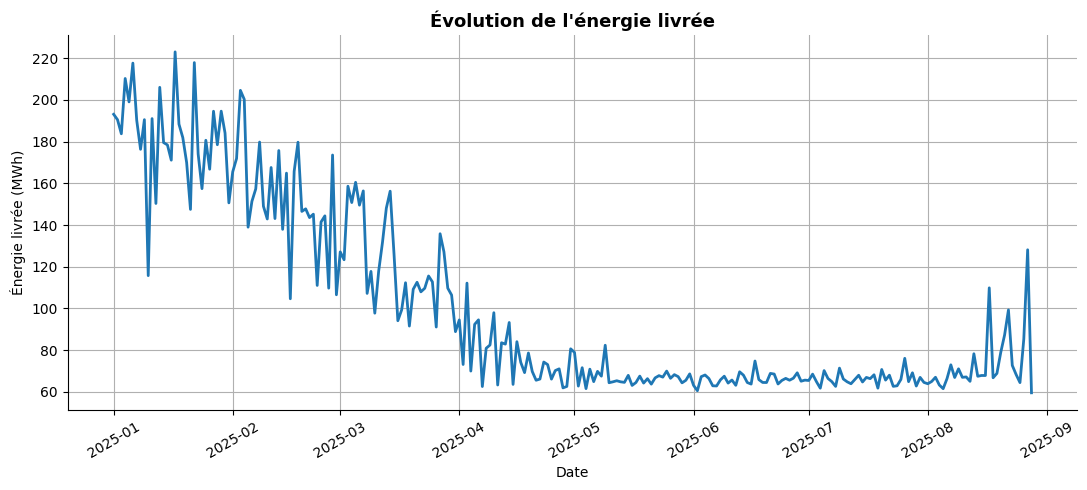

In [10]:
energie_jour = df_clean.groupby("date", as_index=False)["energie_livree_mwh"].sum()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(energie_jour["date"], energie_jour["energie_livree_mwh"], color="#1f77b4", linewidth=2)
ax.set_title("Évolution de l'énergie livrée", fontsize=13, weight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Énergie livrée (MWh)")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()


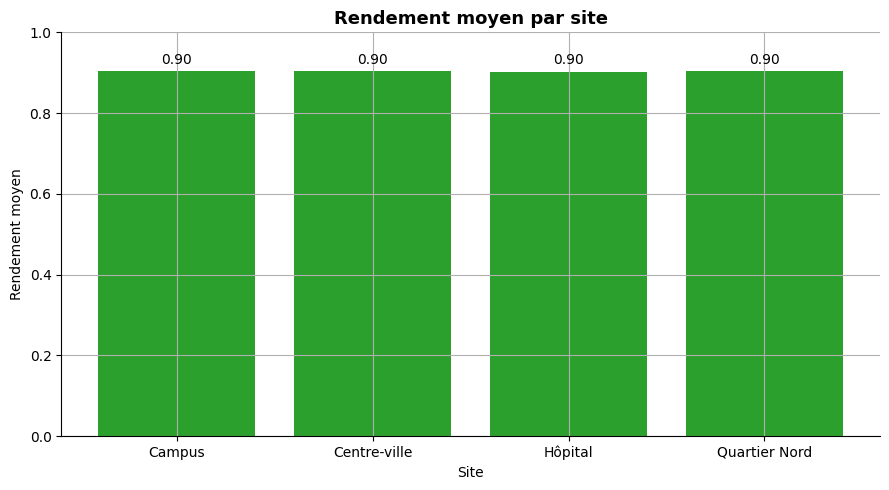

In [11]:
rendement_site = df_clean.groupby("site", as_index=False)["rendement_reseau"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(rendement_site["site"], rendement_site["rendement_reseau"], color="#2ca02c")
ax.set_title("Rendement moyen par site", fontsize=13, weight="bold")
ax.set_xlabel("Site")
ax.set_ylabel("Rendement moyen")
ax.set_ylim(0, 1)
ax.bar_label(bars, fmt="%.2f", padding=3)
fig.tight_layout()
plt.show()


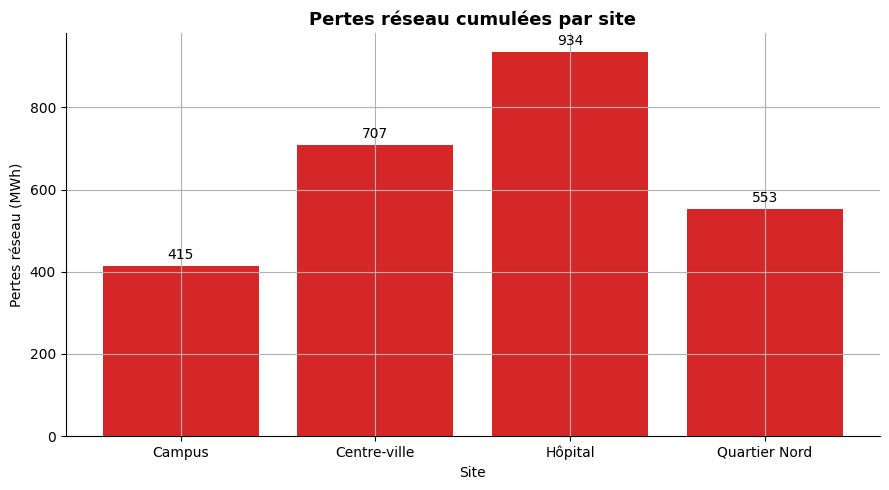

In [12]:
pertes_site = df_clean.groupby("site", as_index=False)["pertes_reseau_mwh"].sum()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(pertes_site["site"], pertes_site["pertes_reseau_mwh"], color="#d62728")
ax.set_title("Pertes réseau cumulées par site", fontsize=13, weight="bold")
ax.set_xlabel("Site")
ax.set_ylabel("Pertes réseau (MWh)")
ax.bar_label(bars, fmt="%.0f", padding=3)
fig.tight_layout()
plt.show()


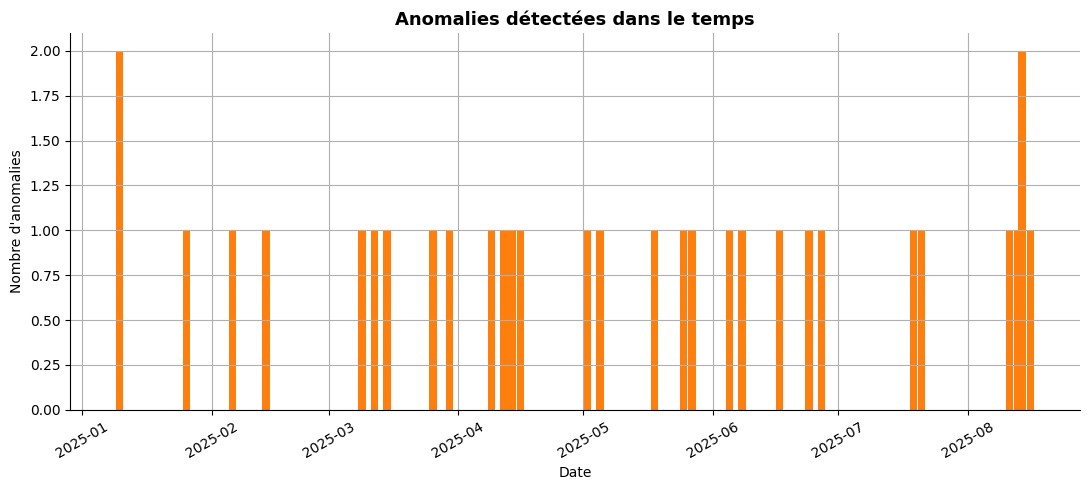

In [13]:
anomalies_jour = anomalies_audit.groupby("date", as_index=False).size()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(anomalies_jour["date"], anomalies_jour["size"], color="#ff7f0e", width=1.8)
ax.set_title("Anomalies détectées dans le temps", fontsize=13, weight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre d'anomalies")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()


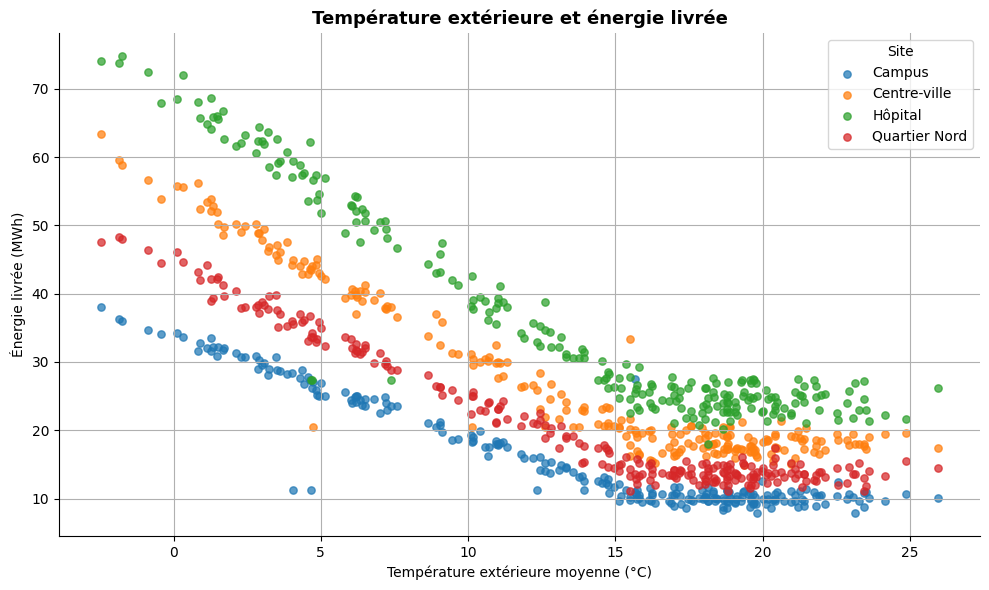

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

for site, data_site in df_clean.groupby("site"):
    ax.scatter(
        data_site["temperature_exterieure_moyenne"],
        data_site["energie_livree_mwh"],
        label=site,
        alpha=0.72,
        s=28,
    )

ax.set_title("Température extérieure et énergie livrée", fontsize=13, weight="bold")
ax.set_xlabel("Température extérieure moyenne (°C)")
ax.set_ylabel("Énergie livrée (MWh)")
ax.legend(title="Site")
fig.tight_layout()
plt.show()


## 8. Synthèse métier

L'analyse permet de suivre les volumes livrés, les pertes réseau et le rendement moyen par site. Les contrôles qualité mettent en évidence des valeurs manquantes, des incohérences d'énergie et quelques pics à investiguer.

Côté métier, ces résultats peuvent aider à prioriser les contrôles sur les sites les plus instables, fiabiliser les flux de données et suivre les rendements anormaux au quotidien.

Les limites restent celles d'un jeu de données simulé : pas de vraie météo, pas de données capteurs et pas d'historique long. Les prochaines étapes utiles seraient une connexion à une base réelle, l'automatisation des contrôles, des alertes sur les anomalies et une prévision simple de consommation.
